# cProfile Visualization based on the results of declearn MNIST Quickrun

This notebook loads a `.prof` file produced by cProfile and visualizes the profiling data.

**Key metrics from cProfile:**
- **tottime** — time spent *inside* a function only, excluding sub-calls
- **cumtime** — time spent inside a function *including* all its sub-calls
- **ncalls** — how many times a function was called
- **percall** — tottime / ncalls
- **self_ratio** — tottime / cumtime — how much work a function does itself vs delegates

## 1. Setup

In [87]:
import pstats
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import numpy as np

## 2. Load profiling data

In [88]:
stats = pstats.Stats("output.prof")
print(f"Total CPU time: {stats.total_tt:.2f}s")

Total CPU time: 191.15s


## 3. Extract and tag function data

Each function is tagged based on its file path to identify which ones belong to declearn.

In [89]:
def is_declearn(filepath):
    """Check if a function belongs to a declearn subpackage."""
    if "declearn/declearn/" not in filepath:
        return False
    parts = filepath.split("declearn/declearn/")[1].split("/")
    if len(parts) <= 1:
        return False
    return parts[0] in [
        "model", "optimizer", "dataset", "training", "metrics",
        "main", "utils", "communication", "messaging"
    ]

def get_declearn_module(filepath):
    """Extract the declearn subpackage name from a file path."""
    parts = filepath.split("declearn/declearn/")[1].split("/")
    return parts[0]

In [90]:
functions = []
for (file, line, name), (cc, nc, tt, ct, callers) in stats.stats.items():
    if tt == 0:
        continue
    functions.append({
        "name": name,
        "file": file,
        "tottime": tt,
        "cumtime": ct,
        "ncalls": nc,
        "self_ratio": tt / ct if ct > 0 else 0,
        "percall": tt / nc if nc > 0 else 0,
        "is_declearn": is_declearn(file),
    })

print(f"Extracted {len(functions)} functions with non-zero tottime")

dl_funcs = [f for f in functions if f["is_declearn"]]

Extracted 17664 functions with non-zero tottime


## 4. Declearn functions ranked by true cost


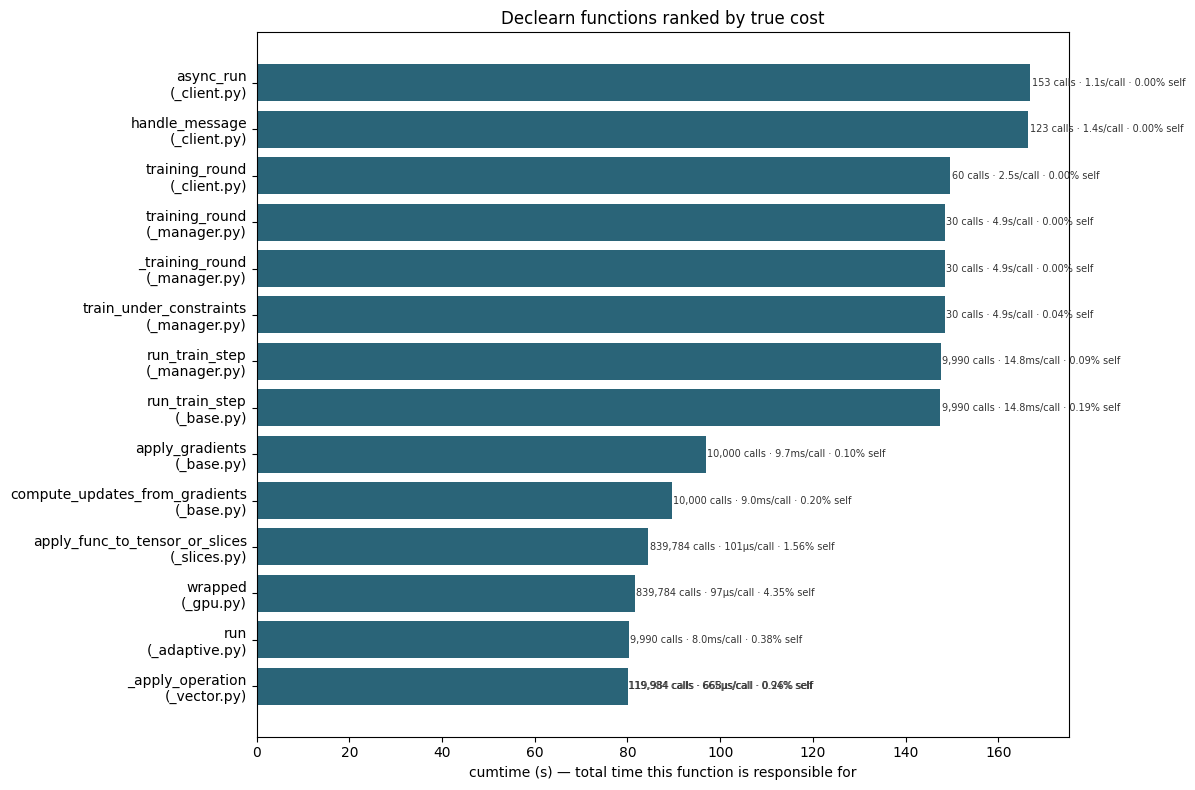

: 

In [ ]:
dl_funcs.sort(key=lambda x: x["cumtime"], reverse=True)
dl_top = dl_funcs[:15]
dl_top.reverse()

labels = [f"{f['name']}\n({os.path.basename(f['file'])})" for f in dl_top]
cumtimes = [f["cumtime"] for f in dl_top]
ncalls = [f["ncalls"] for f in dl_top]
ratios = [f["self_ratio"] for f in dl_top]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(labels, cumtimes, color="#2a6478")

for i, (bar, nc, ratio) in enumerate(zip(bars, ncalls, ratios)):
    w = bar.get_width()
    f = dl_top[i]
    pc = f["cumtime"] / nc if nc > 0 else 0

    if pc >= 1:
        pc_str = f"{pc:.1f}s/call"
    elif pc >= 0.001:
        pc_str = f"{pc*1000:.1f}ms/call"
    else:
        pc_str = f"{pc*1e6:.0f}µs/call"

    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f"{nc:,} calls · {pc_str} · {ratio:.2%} self",
            va='center', fontsize=7, color='#333')

ax.set_xlabel("cumtime (s) — total time this function is responsible for")
ax.set_title("Declearn functions ranked by true cost")
plt.tight_layout()
plt.savefig("cumtime_with_ratio.png", dpi=150)